# CSCI 5922 Final Project
### Anya Lee

In [ ]:
import os
from google.colab import drive

#mount drive
DRIVE_OUT_DIR = "/content/drive/MyDrive/2025-2026/Spring 2026/CSCI 5922: Neural Nets and DL/FinalProject"
drive.mount("/content/drive", force_remount=True)
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/2025-2026/Spring\ 2026/CSCI\ 5922:\ Neural\ Nets\ and\ DL/FinalProject/farm_insects_data.zip

Archive:  /content/drive/MyDrive/2025-2026/Spring 2026/CSCI 5922: Neural Nets and DL/FinalProject/farm_insects_data.zip
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_1.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_10.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_100.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_102.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_104.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_105.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_106.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_107.png  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_108.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_11.jpg  
  inflating: farm_insects/Africanized Honey Bees (Killer Bees)/Image_110.jpg  
  inflating: fa

In [ ]:
# imports
import os
from pathlib import Path

import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from transformers import ViTForImageClassification

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [ ]:
# Constants
SEED = 100
BATCH_SIZE = 32
N_WORKERS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_VAR  = [0.229, 0.224, 0.225]

# Setup
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Preprocessing

In [ ]:
# Define transforms
def get_transform():
    """
    ImaqgeNet preprocessing pipeline for both experiments and models.
        - Resize shorter side to 256 pixels
        - Center crop to 224x224
        - Convert to tensor and normalize using ImageNet stats"""
    return transforms.Compose([
        transforms.Resize(256), # shorter side to 256 pixels
        transforms.CenterCrop(224), # center crop to 224x224
        transforms.ToTensor(), # HWC uint8 → CHW float32 in [0, 1]
        transforms.Normalize( # normalization
            mean=IMAGENET_MEAN,
            std=IMAGENET_VAR,
        )
    ])

def get_augm_transform():
    """
    Data augmentation pipeline for training.
        - Random resized crop to 224x224
        - Random horizontal flip
        - Convert to tensor and normalize using ImageNet stats"""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224), # random crop to 224x224
        transforms.RandomHorizontalFlip(), # random horizontal flip
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # random color jitter
        transforms.ToTensor(), # HWC uint8 → CHW float32 in [0, 1]
        transforms.Normalize( # normalization
            mean=IMAGENET_MEAN,
            std=IMAGENET_VAR,
        )
    ])

In [ ]:
# Function to load the dataset
def load_full_dataset(data_dir, transform):
    """
    Load the full dataset using ImageFolder and apply the given transform.
    Args:
        data_dir (str): Path to the dataset directory.
        transform (torchvision.transforms.Compose): Transformations to apply to the images.
    Returns:
        dataset (torchvision.datasets.ImageFolder): The loaded dataset.
    """
    dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    print(f"Classes: {dataset.classes}") # class names for dangerous farm insects data
    print(f"Total samples: {len(dataset)}") # 1579
    return dataset

## Models

#### ResNet-50

In [ ]:
def load_resnet50(n_classes, pretrained=True):
    """
    Load ResNet-50 and modify the final fully connected layer for our classification task (match n_classes).
    Args:
        n_classes (int): Number of output classes.
        pretrained (bool): Whether to load pretrained ImageNet weights.
    Returns:
        model (torchvision.models.ResNet): The modified ResNet-50 model.
    """
    weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    # return model
    return model.to(device)

#### ViT-B/16

In [ ]:
def load_vit(n_classes, pretrained=True):
    """
    Load ViT-B/16 and modify the final classification head for our classification task (match n_classes).
    Args:
        n_classes (int): Number of output classes.
        pretrained (bool): Whether to load pretrained ImageNet weights.
    Returns:
        model (transformers.ViTForImageClassification): The modified ViT-B/16 model.
    """
    model_name = "google/vit-base-patch16-224-in21k" if pretrained else "google/vit-base-patch16-224"
    model = ViTForImageClassification.from_pretrained(
        model_name,
        num_labels=n_classes,
        ignore_mismatched_sizes=True) # allows head replacement
    # return model
    return model.to(device)

## Forward Pass for Prediction

In [ ]:
def forward_pass(model, dataloader, model_type="resnet"):
    """
    Perform a forward pass through the model and collect predictions and true labels.
    Args:
        model: The neural network model (ResNet or ViT).
        dataloader: DataLoader for the dataset to evaluate on.
        model_type (str): Type of model ("resnet" or "vit") to handle output differences.
    Returns:
        all_preds (numpy.ndarray): Predicted class indices.
        all_labels (numpy.ndarray): True class indices.
    """
    model.eval() # set model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad(): # disable gradient calculation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            if model_type == "resnet":
                outputs = model(images)
            elif model_type == "vit":
                outputs = model(pixel_values=images).logits
            else:
                raise ValueError("Invalid model type. Choose 'resnet' or 'vit'.")

            preds = torch.argmax(outputs, dim=1) # get predicted class indices
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return numpy.array(all_preds), numpy.array(all_labels)

## Evaluation Metrics and Viz

In [ ]:
def compute_metrics(labels, preds, class_names, title, save_dir):
    """
    Compute and print classification metrics, and save a confusion matrix plot.
    Args:
        labels (numpy.ndarray): True class indices.
        preds (numpy.ndarray): Predicted class indices.
        class_names (list): List of class names corresponding to indices.
        title (str): Title for the confusion matrix plot.
        save_dir (str): Directory to save the confusion matrix plot.
    """
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro") # F1 score for each label independently, then averaged (unweighted)
    report = classification_report(labels, preds, target_names=class_names, digits=4)

    print(f"--- {title} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")
    print("Classification Report:")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(14, 11))
    # plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(title, fontsize=14)
    # plt.xticks(rotation=45)
    # plt.yticks(rotation=0)
    plt.tight_layout()

    # Save the confusion matrix plot
    save_path = os.path.join(save_dir, f"{title.replace(' ', '_')}_confusion_matrix.png")
    plt.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"Confusion matrix saved to: {save_path}")

    return {"accuracy": acc, "macro_f1_score": f1}

## Experiment 1: Zero Shot Evaluation

In [ ]:
def experiment1(data_dir, save_dir):
    """
    Load pretrained ResNet-50 and ViT-B/16 (ImageNet weights).
    Evaluate directly on the full Dangerous Farm Insects dataset.
    No training is performed for zero-shot evaluation.
    """
    print("Experiment 1: Zero-Shot Evaluation")

    transform = get_transform()
    dataset = load_full_dataset(data_dir, transform)
    class_names = dataset.classes
    num_classes = len(class_names)
    print(f"Classes ({num_classes}): {class_names}")

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=N_WORKERS,
    )

    # Store results
    results = {}

    # ResNet-50
    print("\nLoading pretrained ResNet-50...")
    resnet = load_resnet50(n_classes=num_classes, pretrained=True)
    labels, preds = forward_pass(resnet, dataloader, model_type="resnet")
    results["resnet50_zeroshot"] = compute_metrics(
        labels, preds, class_names,
        title="Exp1: ResNet-50 Zero-Shot",
        save_dir=save_dir
    )

    # ViT-B/16
    print("\nLoading pretrained ViT-B/16...")
    vit = load_vit(n_classes=num_classes, pretrained=True)
    labels, preds = forward_pass(vit, dataloader, model_type="vit")
    results["vit_zeroshot"] = compute_metrics(
        labels, preds, class_names,
        title="Exp1: ViT-B16 Zero-Shot",
        save_dir=save_dir
    )

    # Side-by-side summary
    print("\nExperiment 1 Summary")
    for k, v in results.items():
        print(f"{k:30s}  Acc={v['accuracy']:.4f}  MacroF1={v['macro_f1_score']:.4f}")

    return results

In [ ]:
# Run Experiment 1
# root_dir = "/content/" # colab
root_dir = "/Users/anya/Documents/CSCI_5922_Neural_Nets_and_DL/FinalProject/" # local
data_dir = root_dir + "data/farm_insects"
save_dir = root_dir + "results/experiment1"

Path(save_dir).mkdir(parents=True, exist_ok=True)


all_results = {}

experiment1_results = experiment1(data_dir, save_dir)
all_results.update(experiment1_results)

Experiment 1: Zero-Shot Evaluation
Classes: ['Africanized Honey Bees (Killer Bees)', 'Aphids', 'Armyworms', 'Brown Marmorated Stink Bugs', 'Cabbage Loopers', 'Citrus Canker', 'Colorado Potato Beetles', 'Corn Borers', 'Corn Earworms', 'Fall Armyworms', 'Fruit Flies', 'Spider Mites', 'Thrips', 'Tomato Hornworms', 'Western Corn Rootworms']
Total samples: 1579
Classes (15): ['Africanized Honey Bees (Killer Bees)', 'Aphids', 'Armyworms', 'Brown Marmorated Stink Bugs', 'Cabbage Loopers', 'Citrus Canker', 'Colorado Potato Beetles', 'Corn Borers', 'Corn Earworms', 'Fall Armyworms', 'Fruit Flies', 'Spider Mites', 'Thrips', 'Tomato Hornworms', 'Western Corn Rootworms']

Loading pretrained ResNet-50...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in

--- Exp1: ResNet-50 Zero-Shot ---
Accuracy: 0.1007
Macro F1 Score: 0.0446
Classification Report:
                                      precision    recall  f1-score   support

Africanized Honey Bees (Killer Bees)     0.0000    0.0000    0.0000         0
                              Aphids     0.0000    0.0000    0.0000        29
                           Armyworms     0.0000    0.0000    0.0000         2
         Brown Marmorated Stink Bugs     0.0000    0.0000    0.0000         0
                     Cabbage Loopers     0.0000    0.0000    0.0000         1
                       Citrus Canker     0.0481    0.0397    0.0435       126
             Colorado Potato Beetles     0.0000    0.0000    0.0000         0
                         Corn Borers     0.0088    0.5000    0.0172         2
                       Corn Earworms     0.4091    0.0846    0.1402       532
                      Fall Armyworms     0.1364    0.0463    0.0691       324
                         Fruit Flies     0.0

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_

--- Exp1: ViT-B16 Zero-Shot ---
Accuracy: 0.0443
Macro F1 Score: 0.0419
Classification Report:
                                      precision    recall  f1-score   support

Africanized Honey Bees (Killer Bees)     0.0208    0.0215    0.0212        93
                              Aphids     0.0230    0.0169    0.0195       118
                           Armyworms     0.0105    0.0278    0.0153        36
         Brown Marmorated Stink Bugs     0.0000    0.0000    0.0000       264
                     Cabbage Loopers     0.0385    0.0323    0.0351       124
                       Citrus Canker     0.0192    0.0690    0.0301        29
             Colorado Potato Beetles     0.1875    0.3559    0.2456        59
                         Corn Borers     0.0088    0.0357    0.0141        28
                       Corn Earworms     0.1818    0.0543    0.0837       368
                      Fall Armyworms     0.0909    0.0952    0.0930       105
                         Fruit Flies     0.010

## Experiment 2: Fine-Tuning and Transfer Learning

In [ ]:
# Constants for training
EPOCHS = 20
# Regularization
LR = 2e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5

# Train/Val/Test split
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

In [ ]:
def load_split_datasets(data_dir):
    """
    Load and split dataset into train/val/test for second experiment.
    Train split has augmented transforms; val/test have standard ImageNet transforms.
    Args:
        data_dir (str): Path to the dataset directory.
    """
    # Load the full dataset with standard transforms
    # full_dataset = load_full_dataset(root=data_dir, transform=get_transform())
    full_dataset = datasets.ImageFolder(root=data_dir, transform=get_transform())


    # Calculate split sizes
    total_size = len(full_dataset)
    train_size = int(TRAIN_SPLIT * total_size)
    val_size = int(VAL_SPLIT* total_size)
    test_size = total_size - train_size - val_size

    # Split the dataset
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    # Apply augmentation to the training dataset
    train_dataset.dataset = datasets.ImageFolder(
        root=data_dir, transform=get_augm_transform()
    )
    # Get class names
    class_names = full_dataset.classes

    print(f"Train samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset, class_names

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, model_type):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()

          if model_type == "vit":
              outputs = model(pixel_values=images).logits
          else:
              outputs = model(images)

          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          running_loss += loss.item() * images.size(0)
          correct += (outputs.argmax(1) == labels).sum().item()
          total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, dataloader, criterion, model_type):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            if model_type == "vit":
                outputs = model(pixel_values=images).logits
            else:
                outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [ ]:
def fine_tune(model, train_loader, val_loader, model_name, model_type, save_dir):
    """
    Full fine-tuning loop with:
      - Cross-entropy loss
      - Adam optimizer
      - ReduceLROnPlateau scheduler
      - Early stopping on val loss
      - Best-model checkpoint saving
    Returns history dict with train/val loss and accuracy per epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_val_loss = float("inf")
    patience_counter = 0
    checkpoint_path = Path(save_dir) / f"{model_name}_best.pt"

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"\n  Fine-tuning {model_name} for up to {EPOCHS} epochs...")
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, model_type
        )
        val_loss, val_acc = validate(model, val_loader, criterion, model_type)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"  Epoch {epoch:02d}/{EPOCHS}  "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}"
        )

        # Checkpoint best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    # Reload best weights before returning
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"  Best model restored from {checkpoint_path}")
    return history


In [ ]:
# Plotting
def plot_training_history(history, model_name, save_dir):
    """Plot and save training/validation loss and accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    save_path = Path(save_dir) / f"{model_name}_training_curves.png"
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Training curves saved → {save_path}")


In [ ]:
# Run Experiment 2
def experiment2(data_dir, save_dir):
    """
    Fine-tune ResNet-50 and ViT-B/16 on the Dangerous Farm Insects dataset.
    Evaluate on held-out test set and compare with Experiment 1 zero-shot results.
    """
    print("Experiment 2: Fine-Tuning")
    # Load data
    train_ds, val_ds, test_ds, class_names = load_split_datasets(data_dir)
    num_classes = len(class_names)
    print(f"Classes ({num_classes}): {class_names}")

    # DataLoaders
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=N_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)

    results = {}

    # ResNet-50
    print("\nFine-tuning ResNet-50...")
    resnet = load_resnet50(n_classes=num_classes, pretrained=True)
    history_resnet = fine_tune(
        resnet, train_loader, val_loader,
        model_name="resnet50_finetuned",
        model_type="resnet",
        save_dir=save_dir
    )
    plot_training_history(history_resnet, "ResNet-50", save_dir)

    labels, preds = forward_pass(resnet, test_loader, model_type="resnet")
    results["resnet50_finetuned"] = compute_metrics(
        labels, preds, class_names,
        title="Exp2: ResNet-50 Fine-Tuned",
        save_dir=save_dir
    )

    # ViT-B/16
    print("\nFine-tuning ViT-B/16...")
    vit = load_vit(n_classes=num_classes, pretrained=True)
    history_vit = fine_tune(
        vit, train_loader, val_loader,
        model_name="vit_finetuned",
        model_type="vit",
        save_dir=save_dir
    )
    plot_training_history(history_vit, "ViT-B16", save_dir)

    labels, preds = forward_pass(vit, test_loader, model_type="vit")
    results["vit_finetuned"] = compute_metrics(
        labels, preds, class_names,
        title="Exp2: ViT-B16 Fine-Tuned",
        save_dir=save_dir
    )

    # Summary
    print("\nExperiment 2 Summary")
    for k, v in results.items():
        print(f"  {k:30s}  Acc={v['accuracy']:.4f}  MacroF1={v['macro_f1_score']:.4f}")

    return results

In [ ]:
# Run Experiment 2
root_dir = "/content/" # colab
# root_dir = "/Users/anya/Documents/CSCI_5922_Neural_Nets_and_DL/FinalProject/" # local
data_dir = root_dir + "farm_insects"
save_dir = root_dir + "results/experiment2"

Path(save_dir).mkdir(parents=True, exist_ok=True)

# all_results ={} already defined before exp 1
experiment2_results = experiment2(data_dir, save_dir)
all_results.update(experiment2_results)

Experiment 2: Fine-Tuning
Train samples: 1105
Validation samples: 236
Test samples: 238
Classes (15): ['Africanized Honey Bees (Killer Bees)', 'Aphids', 'Armyworms', 'Brown Marmorated Stink Bugs', 'Cabbage Loopers', 'Citrus Canker', 'Colorado Potato Beetles', 'Corn Borers', 'Corn Earworms', 'Fall Armyworms', 'Fruit Flies', 'Spider Mites', 'Thrips', 'Tomato Hornworms', 'Western Corn Rootworms']

Fine-tuning ResNet-50...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Fine-tuning resnet50_finetuned for up to 20 epochs...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings

  Epoch 01/20  train_loss=1.5329  train_acc=0.5493  val_loss=1.1218  val_acc=0.6271


...

  Epoch 09/20  train_loss=0.1484  train_acc=0.9665  val_loss=0.6421  val_acc=0.7924


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

  Epoch 10/20  train_loss=0.0839  train_acc=0.9855  val_loss=0.6393  val_acc=0.8008
  Early stopping at epoch 10.
  Best model restored from /content/results/experiment2/vit_finetuned_best.pt
  Training curves saved → /content/results/experiment2/ViT-B16_training_curves.png


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


--- Exp2: ViT-B16 Fine-Tuned ---
Accuracy: 0.7815
Macro F1 Score: 0.7857
Classification Report:
                                      precision    recall  f1-score   support

Africanized Honey Bees (Killer Bees)     1.0000    0.9333    0.9655        15
                              Aphids     0.7857    0.7857    0.7857        14
                           Armyworms     0.2857    0.4444    0.3478         9
         Brown Marmorated Stink Bugs     0.8667    1.0000    0.9286        13
                     Cabbage Loopers     0.8667    0.6842    0.7647        19
                       Citrus Canker     0.9444    0.8095    0.8718        21
             Colorado Potato Beetles     1.0000    0.8750    0.9333        16
                         Corn Borers     0.8462    0.4583    0.5946        24
                       Corn Earworms     0.5217    0.7500    0.6154        16
                      Fall Armyworms     0.4762    0.6250    0.5405        16
                         Fruit Flies     1.00

In [ ]:
print(all_results)

{'resnet50_zeroshot': {'accuracy': 0.10069664344521849, 'macro_f1_score': 0.04464306375811534}, 'vit_zeroshot': {'accuracy': 0.044331855604813175, 'macro_f1_score': 0.04191547964163212}, 'resnet50_finetuned': {'accuracy': 0.7142857142857143, 'macro_f1_score': 0.7121441389608153}, 'vit_finetuned': {'accuracy': 0.7815126050420168, 'macro_f1_score': 0.7856999181199775}}


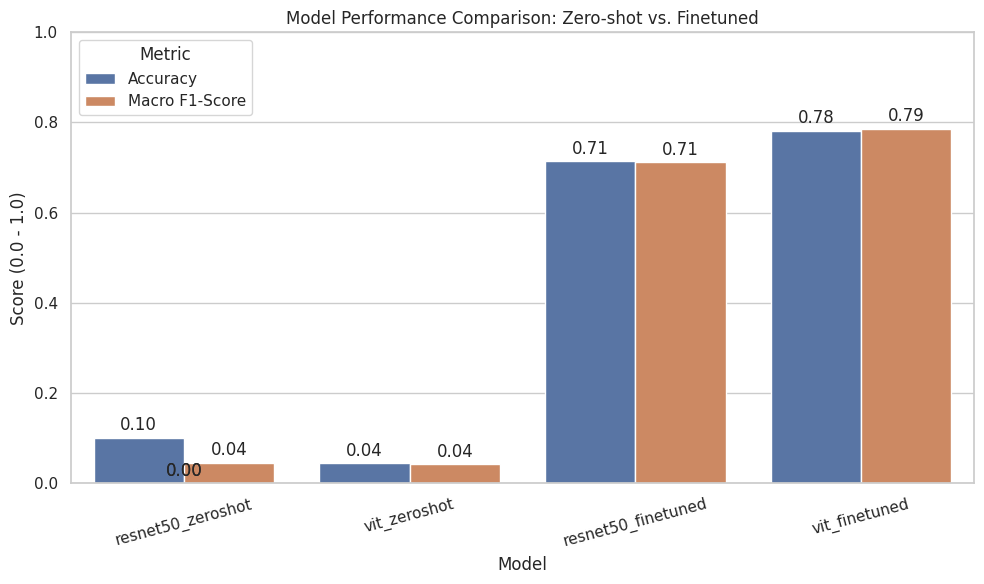

In [ ]:
import pandas as pd

# Transform dictionary to a long-format DataFrame
df = pd.DataFrame(all_results).T.reset_index()
df.columns = ['Model', 'Accuracy', 'Macro F1-Score']
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points')

plt.title('Model Performance Comparison: Zero-shot vs. Finetuned')
plt.ylim(0, 1.0) # Set scale to 0-1 for percentage-based metrics
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "model_comparison.png"), dpi=150)
plt.show()